まずは、lifelinesをインストールします。

In [1]:
# thank you https://www.kaggle.com/code/samanfatima7/cibmtr-bridging-gaps-in-survival
# thank you https://www.kaggle.com/code/cdeotte/pip-install-lifelines
# pip download lifelines
!pip install /kaggle/input/pip-install-lifelines/autograd-1.7.0-py3-none-any.whl
!pip install /kaggle/input/pip-install-lifelines/autograd-1.7.0-py3-none-any.whl
!pip install /kaggle/input/pip-install-lifelines/autograd-gamma-0.5.0.tar.gz
!pip install /kaggle/input/pip-install-lifelines/interface_meta-1.3.0-py3-none-any.whl
!pip install /kaggle/input/pip-install-lifelines/formulaic-1.0.2-py3-none-any.whl
!pip install /kaggle/input/pip-install-lifelines/lifelines-0.30.0-py3-none-any.whl

Processing /kaggle/input/pip-install-lifelines/autograd-1.7.0-py3-none-any.whl
autograd is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.
Processing /kaggle/input/pip-install-lifelines/autograd-1.7.0-py3-none-any.whl
autograd is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.
Processing /kaggle/input/pip-install-lifelines/autograd-gamma-0.5.0.tar.gz
  Preparing metadata (setup.py) ... done
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=f0a8aa249b962e530237ab8031c130e48b5173a8819e6d039ccdfb256555f909
  Stored in directory: /root/.cache/pip/wheels/6b/b5/e0/4c79e15c0b5f2c15ecf613c720bb20daab20a666eb67135155
Successfully built autograd-gamma
Processing /kaggle/input/pip-install-lifelines/interface_meta-1.3.0-py3-none-any.whl
Processing /kaggle/input/pip-install-lifelines/formulaic-1.0.2-

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
import lightgbm as lgb

from sklearn.preprocessing import LabelEncoder

from lifelines import KaplanMeierFitter

データの読み込み

In [3]:
train_df = pd.read_csv('/kaggle/input/equity-post-HCT-survival-predictions/train.csv',index_col='ID')
test_df = pd.read_csv('/kaggle/input/equity-post-HCT-survival-predictions/test.csv', index_col='ID')
sub = pd.read_csv('/kaggle/input/equity-post-HCT-survival-predictions/sample_submission.csv')

ターゲットをefs, efs_timeとして分けます

efsについては、classification, efs_timeについてはregressionで予測します。

c-indexを最後に計算して、提出します。

In [4]:
target_efs = train_df['efs'] # classification
target_efs_time = train_df['efs_time'] # regression

In [5]:
# target_efsについてはclassification, target_efs_timeについてはregression最後にlifelinesからKaplanMeierFitterでtargetを作成し提出する

train = train_df.drop(['efs', 'efs_time'], axis=1)
test = test_df

データフレームを数値と、カテゴリに分けて、NaNを埋めます。数値のほうはmode、カテゴリのほうはmissingで埋めます。

In [6]:
train_numerical = train.select_dtypes(include=[np.number])
train_numerical.fillna(train_numerical.mode(), inplace=True)
train_categorical = train.select_dtypes(exclude=[np.number])
train_categorical = train.select_dtypes(exclude=[np.number]).fillna('missing')


# testデータについても同様に処理する 

test_numerical = test.select_dtypes(include=[np.number])
test_numerical.fillna(train_numerical.mode(), inplace=True)
test_categorical = test.select_dtypes(exclude=[np.number]).fillna('missing')


for col in train_categorical.columns:
    le = LabelEncoder()
    train_categorical[col] = le.fit_transform(train_categorical[col].astype('category'))
    test_categorical[col] = le.transform(test_categorical[col].astype('category'))

数値型について、ヒストグラムをプロットして様子を見ます

In [7]:
train_numerical.isnull().sum()

hla_match_c_high       4619
hla_high_res_8         5828
hla_low_res_6          3270
hla_high_res_6         5284
hla_high_res_10        7162
hla_match_dqb1_high    5199
hla_nmdp_6             4197
hla_match_c_low        2800
hla_match_drb1_low     2643
hla_match_dqb1_low     4194
year_hct                  0
hla_match_a_high       4301
donor_age              1807
hla_match_b_low        2565
age_at_hct                0
hla_match_a_low        2390
hla_match_b_high       4088
comorbidity_score       477
karnofsky_score         870
hla_low_res_8          3653
hla_match_drb1_high    3352
hla_low_res_10         5064
dtype: int64

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


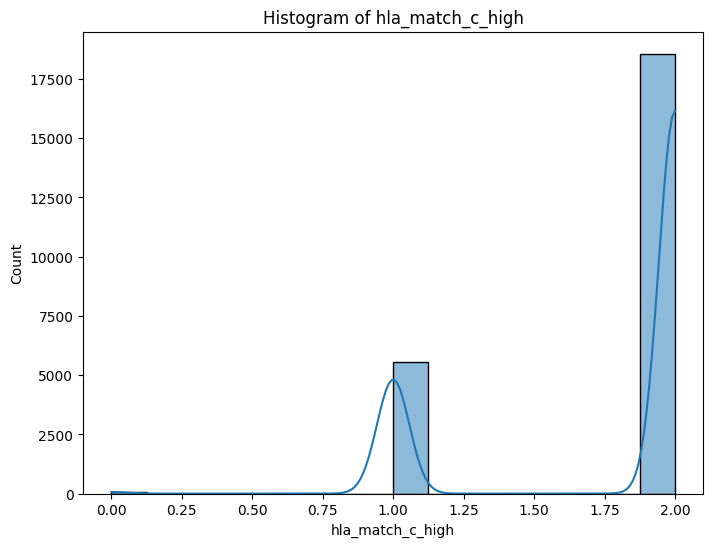

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


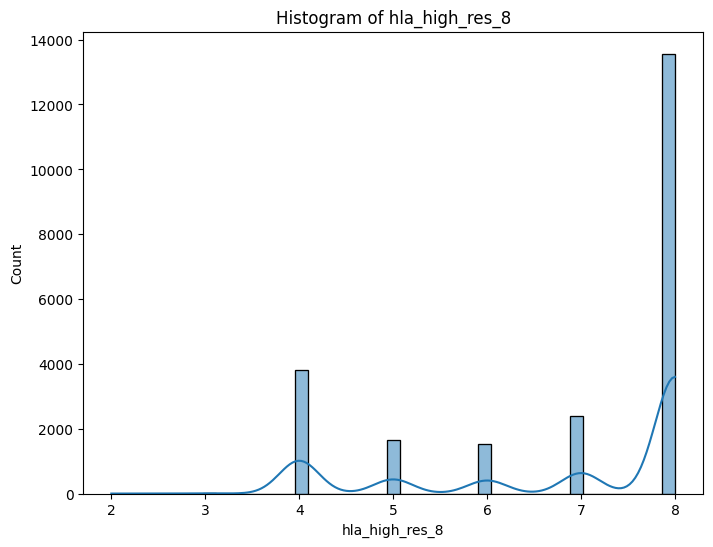

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


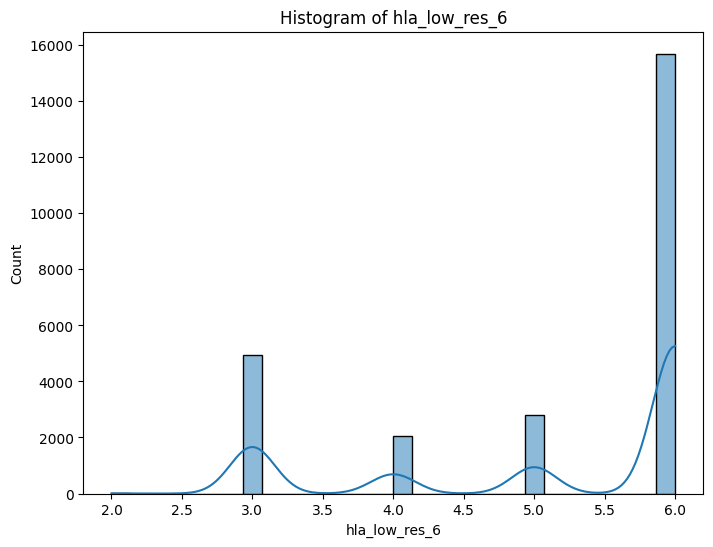

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


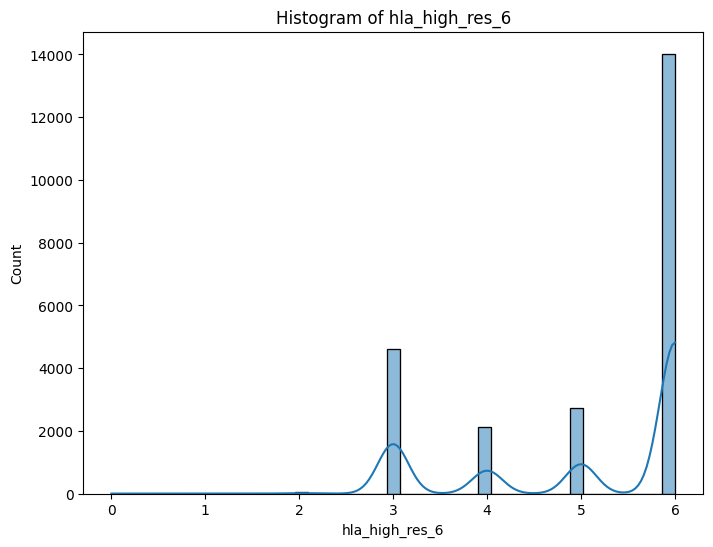

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


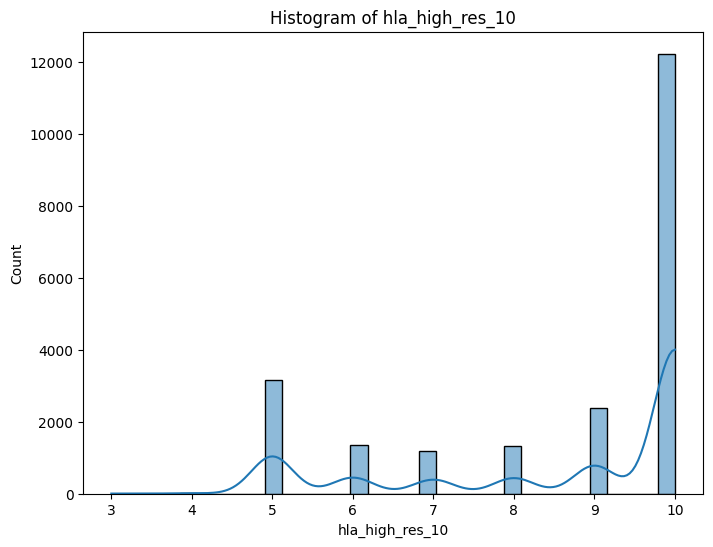

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


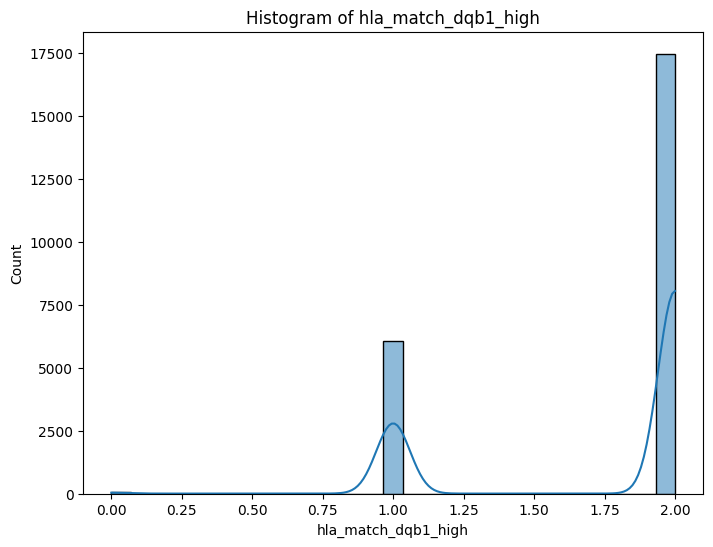

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


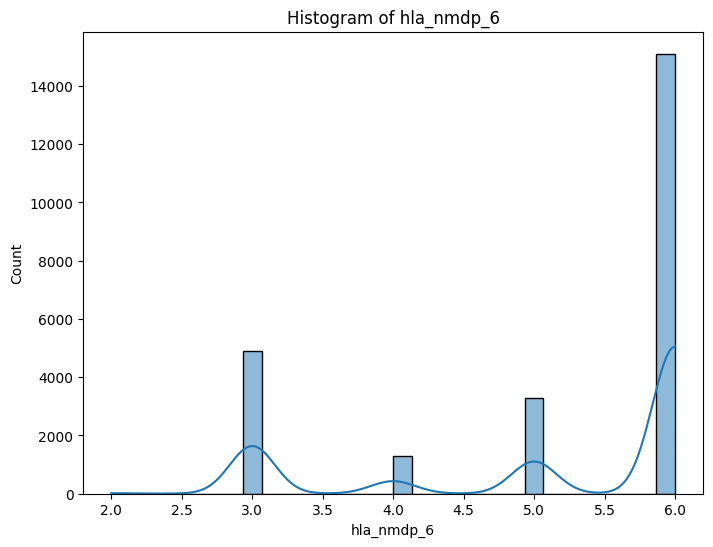

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


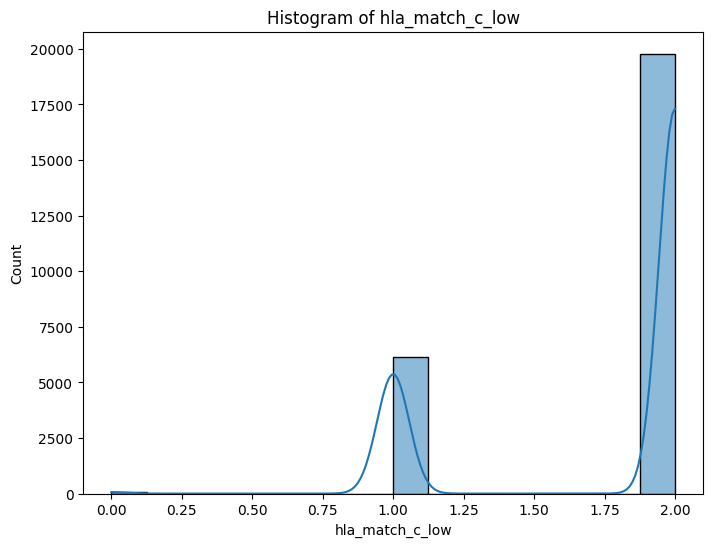

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


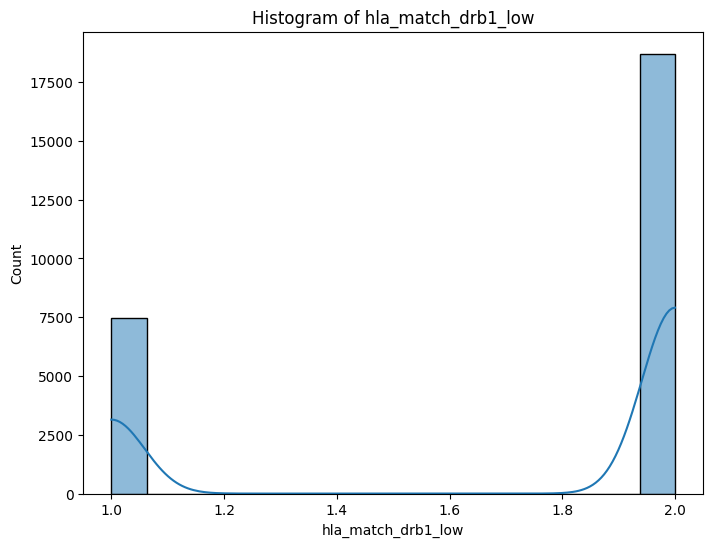

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


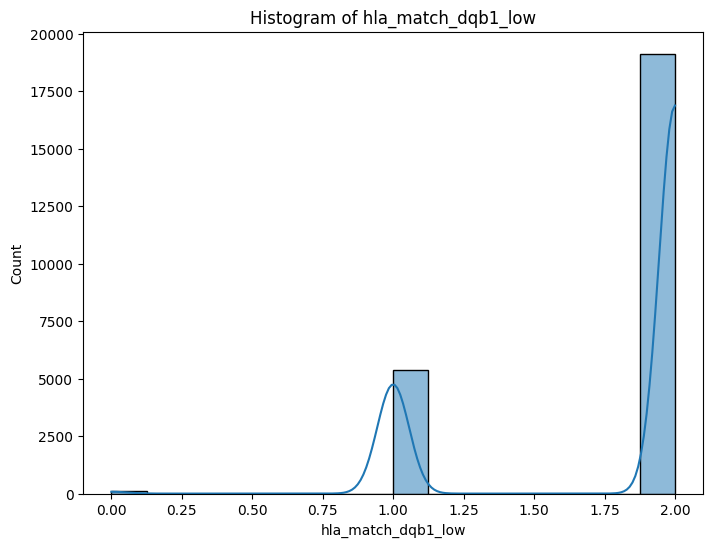

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


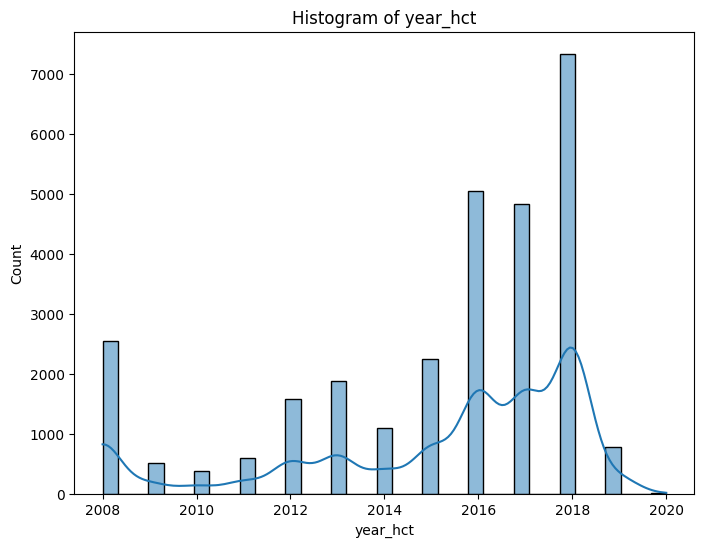

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


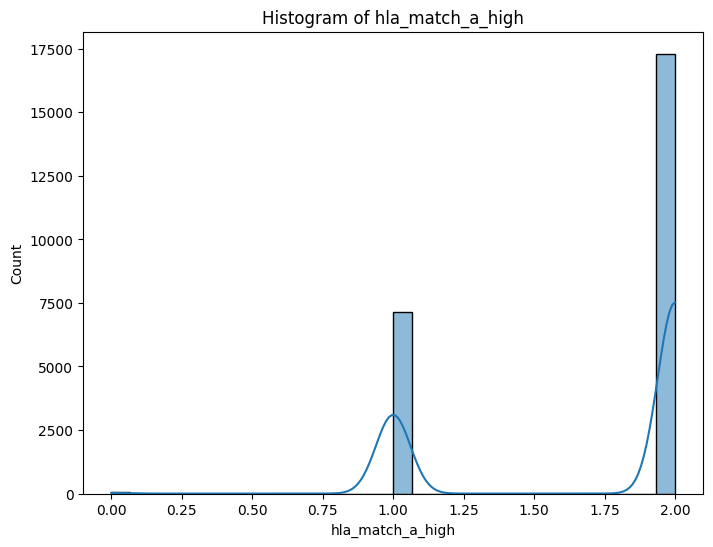

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


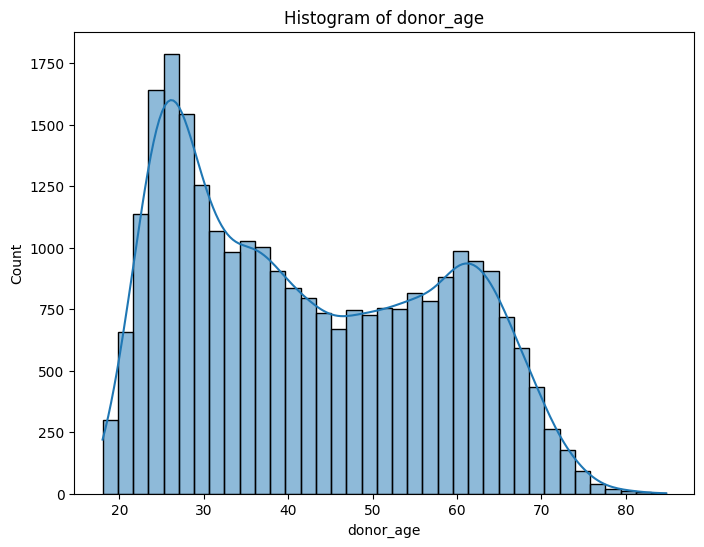

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


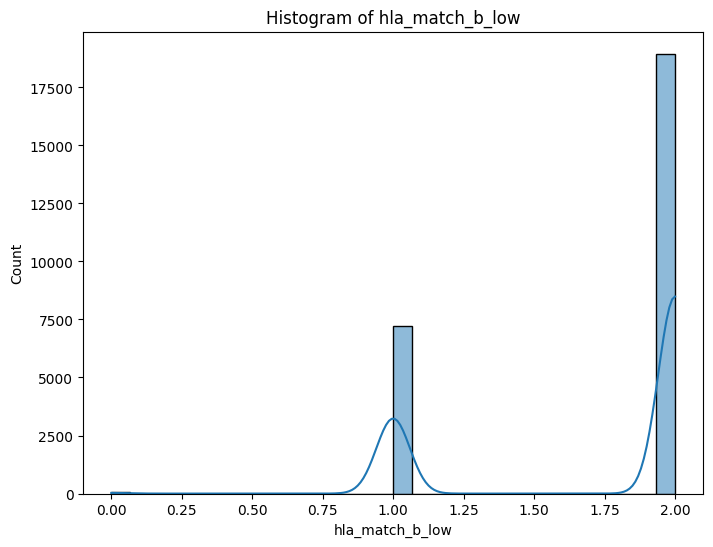

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


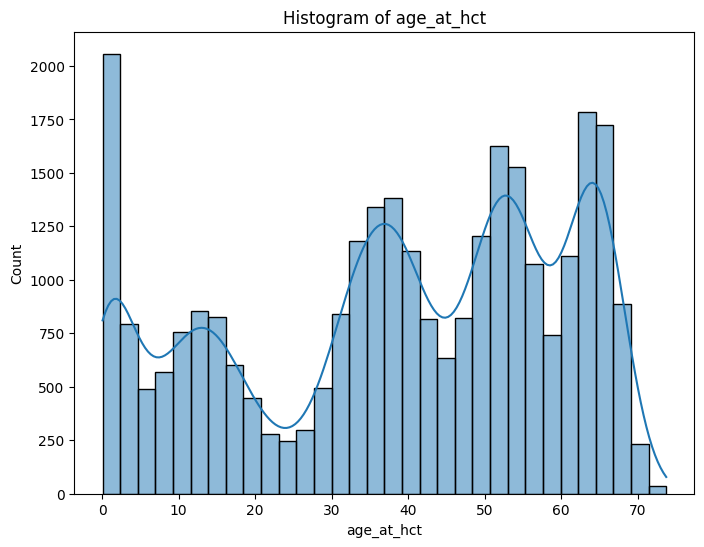

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


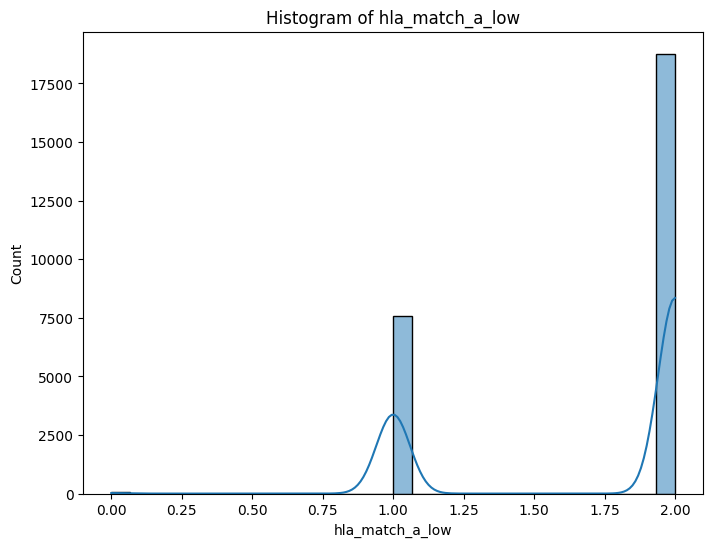

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


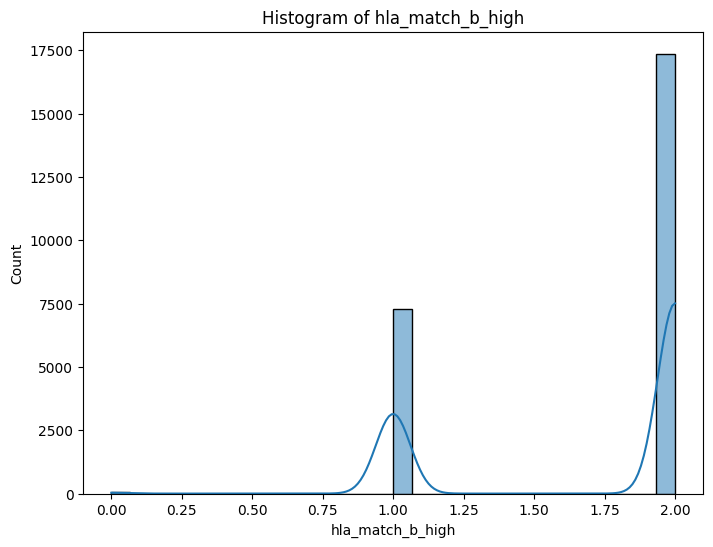

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


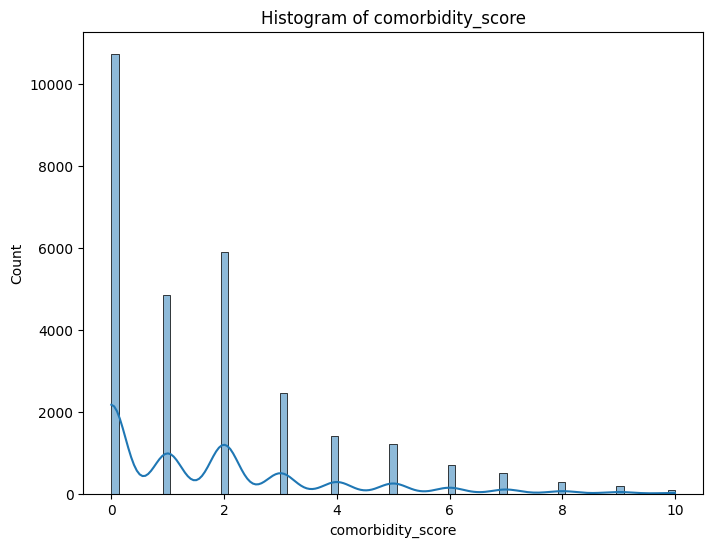

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


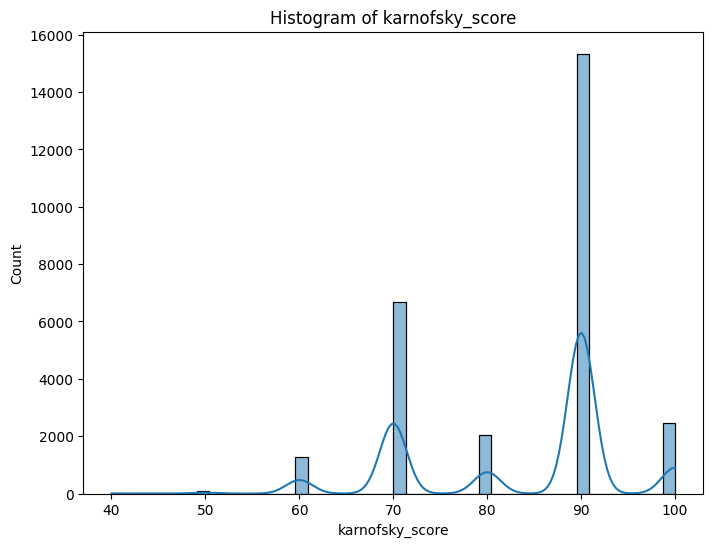

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


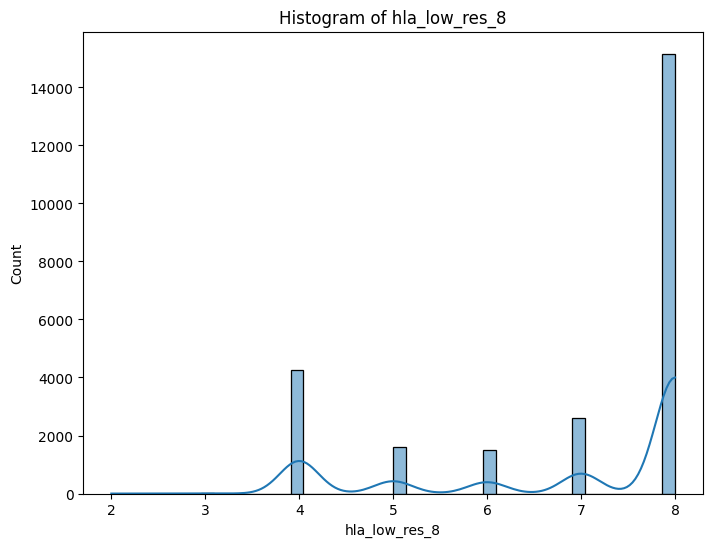

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


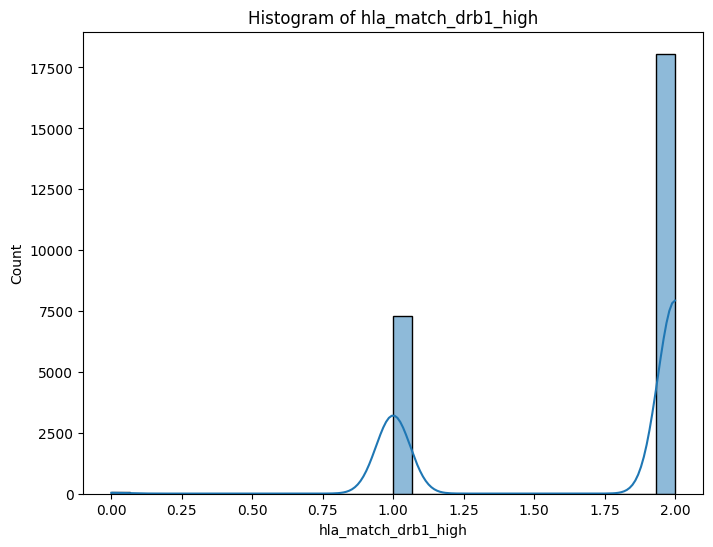

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


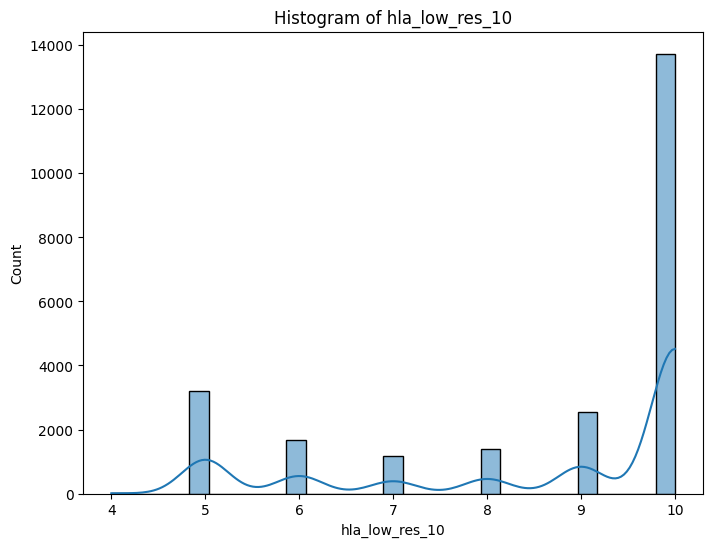

In [8]:


for col in train_numerical.columns:
  plt.figure(figsize=(8, 6))
  sns.histplot(train_numerical[col], kde=True)
  plt.title(f'Histogram of {col}')
  plt.show()

数値型のほうに分けたものが、医療では非連続なスコアなので、カテゴリ型とみなせるかもしれません

In [9]:
for col in train_numerical.columns:
    print(train_numerical[col].value_counts())

# 数値ではあるが、非連続で、離散値（カテゴリー）でもあることがわかる

hla_match_c_high
2.0    18566
1.0     5536
0.0       79
Name: count, dtype: int64
hla_high_res_8
8.0    13569
4.0     3820
7.0     2385
5.0     1648
6.0     1520
3.0       28
2.0        2
Name: count, dtype: int64
hla_low_res_6
6.0    15690
3.0     4955
5.0     2808
4.0     2055
2.0       22
Name: count, dtype: int64
hla_high_res_6
6.0    14022
3.0     4596
5.0     2726
4.0     2128
2.0       43
0.0        1
Name: count, dtype: int64
hla_high_res_10
10.0    12233
5.0      3161
9.0      2369
6.0      1355
8.0      1314
7.0      1180
4.0        25
3.0         1
Name: count, dtype: int64
hla_match_dqb1_high
2.0    17468
1.0     6056
0.0       77
Name: count, dtype: int64
hla_nmdp_6
6.0    15105
3.0     4888
5.0     3296
4.0     1279
2.0       35
Name: count, dtype: int64
hla_match_c_low
2.0    19782
1.0     6139
0.0       79
Name: count, dtype: int64
hla_match_drb1_low
2.0    18710
1.0     7447
Name: count, dtype: int64
hla_match_dqb1_low
2.0    19131
1.0     5384
0.0       91
Name: count

NaNが埋まっているか確認します

In [10]:
train_numerical.isnull().sum(), test_numerical.isnull().sum()

(hla_match_c_high       4619
 hla_high_res_8         5828
 hla_low_res_6          3270
 hla_high_res_6         5284
 hla_high_res_10        7162
 hla_match_dqb1_high    5199
 hla_nmdp_6             4197
 hla_match_c_low        2800
 hla_match_drb1_low     2643
 hla_match_dqb1_low     4194
 year_hct                  0
 hla_match_a_high       4301
 donor_age              1807
 hla_match_b_low        2565
 age_at_hct                0
 hla_match_a_low        2390
 hla_match_b_high       4088
 comorbidity_score       477
 karnofsky_score         870
 hla_low_res_8          3653
 hla_match_drb1_high    3352
 hla_low_res_10         5064
 dtype: int64,
 hla_match_c_high       1
 hla_high_res_8         1
 hla_low_res_6          0
 hla_high_res_6         0
 hla_high_res_10        1
 hla_match_dqb1_high    0
 hla_nmdp_6             0
 hla_match_c_low        0
 hla_match_drb1_low     0
 hla_match_dqb1_low     0
 year_hct               0
 hla_match_a_high       0
 donor_age              2
 hla_matc

数値型のデータフレームには、カテゴリとみなせるものがあるようですので、そちらは整数化し、カテゴリ型に分けてみます


In [11]:
# train_numericalを離散値と連続値に分ける

train_numerical_category = train_numerical.drop(['year_hct', 'donor_age', 'age_at_hct'], axis = 1).fillna(0).astype(int).astype('category')
train_numerical_numeric = train_numerical[['year_hct', 'donor_age', 'age_at_hct']].astype(float)
train_numerical = pd.concat([train_numerical_numeric, train_numerical_category], axis = 1)
train_numerical.head()

,year_hct,donor_age,age_at_hct,hla_match_c_high,hla_high_res_8,hla_low_res_6,hla_high_res_6,hla_high_res_10,hla_match_dqb1_high,hla_nmdp_6,...,hla_match_dqb1_low,hla_match_a_high,hla_match_b_low,hla_match_a_low,hla_match_b_high,comorbidity_score,karnofsky_score,hla_low_res_8,hla_match_drb1_high,hla_low_res_10
ID,,,,,,,,,,,,,,,,,,,,,
0,2016.0,23.57,9.942,2,8,6,6,10,2,6,...,2,2,2,2,2,0,90,8,2,10
1,2008.0,72.29,43.705,2,8,6,6,10,2,6,...,2,2,2,2,2,3,90,8,2,10
2,2019.0,NaN,33.997,2,8,6,6,10,2,6,...,2,2,2,2,2,0,90,8,2,10
3,2009.0,29.23,43.245,2,8,6,6,10,2,6,...,2,2,2,2,2,0,90,8,2,10
4,2018.0,56.81,29.740,2,8,6,6,10,2,5,...,2,2,2,2,2,1,90,8,2,10


In [12]:
train_numerical.describe().T

,count,mean,std,min,25%,50%,75%,max
year_hct,28800.0,2015.179444,3.153914,2008.000,2013.000,2016.000,2018.00000,2020.000
donor_age,26993.0,42.510889,15.251587,18.010,28.447,40.062,56.13000,84.800
age_at_hct,28800.0,38.663162,21.147581,0.044,19.539,41.006,55.96525,73.726


In [13]:
target_efs = target_efs.astype(int)

In [14]:
train_df_efs = pd.concat([train_numerical, train_categorical, target_efs], axis = 1)
train_df_efs_time = pd.concat([train_numerical, train_categorical, target_efs_time], axis = 1)

testのデータフレームについても、同様に処理します

In [15]:
test_numerical_category = test_numerical.drop(['year_hct', 'donor_age', 'age_at_hct'], axis = 1).fillna(0).astype(int).astype('category')

test_numerical_numeric = test_numerical[['year_hct', 'donor_age', 'age_at_hct']].astype(float)

test_numerical = pd.concat([test_numerical_numeric, test_numerical_category], axis = 1)


In [16]:
test_df_efs = pd.concat([test_numerical, test_categorical], axis = 1)
test_df_efs_time = pd.concat([test_numerical, test_categorical], axis = 1)

testデータについては、linfelinesからKaplanMeierFitterを用いて、targetを出すときには、実質efs_timeの予測のみ必要になりますので、efs_timeのみ回帰で予測します。lightGBMを用います

In [17]:
# efs_timeについてlightgbmを使って回帰モデルを作る


X_train, X_test, y_train, y_test = train_test_split(train_df_efs_time.drop('efs_time', axis=1), train_df_efs_time['efs_time'], test_size=0.2, random_state=42)

dtrain = lgb.Dataset(X_train, label=y_train)

dvalid = lgb.Dataset(X_test, label=y_test)

params = {
    
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1
    
}

model_lgb_time = lgb.train(params, dtrain, valid_sets=[dtrain, dvalid], num_boost_round=1000)   

y_pred_lgb_time = model_lgb_time.predict(X_test, num_iteration=model_lgb_time.best_iteration)

from sklearn.metrics import mean_squared_error
print('rmse:', np.sqrt(mean_squared_error(y_test, y_pred_lgb_time)))

rmse: 22.93548014407385


In [18]:
prediction_efs_time = model_lgb_time.predict(test_df_efs_time)
prediction_efs_time

array([33.43483163,  9.84315959, 18.45696965])

<Axes: xlabel='timeline'>

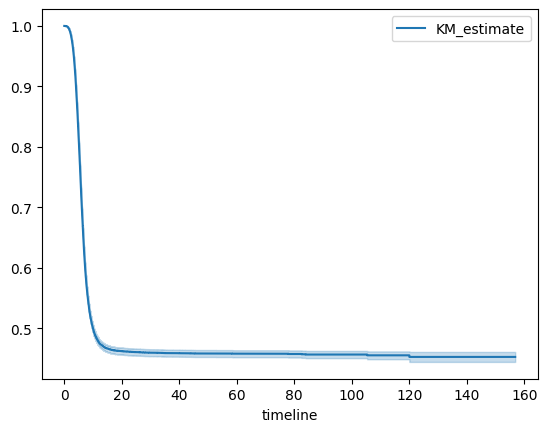

In [19]:
# train_data, test_dataを用いて、c-indexを計算する
kmf = KaplanMeierFitter()

event = target_efs
time = target_efs_time

kmf = KaplanMeierFitter()
kmf.fit(time, event_observed=event)
kmf.plot()

In [20]:
# 提出するために、kmfを用いて、c-indexを計算する
time_test = prediction_efs_time
survival_probabilities = kmf.survival_function_at_times(time_test).values
survival_probabilities 

array([0.45949494, 0.502648  , 0.46299784])

これで、submissionファイルのpredictionの部分ができました

In [21]:
predictions = pd.DataFrame(
    {
        "ID": test.index,
        "prediction": survival_probabilities,
    }
)
sub=predictions

In [22]:
sub.to_csv('submission.csv', index = False)